In [1]:

import numpy as np
import matplotlib.pyplot as plt

import qil_SpinHamiltonian.spin_hamiltonian as spin
import qil_SpinHamiltonian.search as spinSearch
h=spin.h

# Manual Instantiation

In [2]:
Espin=0
Ispin=5/2

#Natural units of the program are GHz, T and radians so conversions must be made
M=np.matrix(np.diag([2.86,3.05,11.56]))*10*1E6*h
Q=np.matrix(np.diag([-0.5624,0.5624,4.4450]))*1E6*h
alpha,beta,gamma=np.array([-99.8,55.8,-40])*np.pi/180

#No convention for rotation is specified in the data source, but ZYZ is typical
M=spin.tensorRotation(M,[alpha,beta,gamma],conv='ZYZ')
Q=spin.tensorRotation(Q,[alpha,beta,gamma],conv='ZYZ')

#Instantiates the class and sets up dimensions and spin matricies
ground = spin.cSpinHamiltonian(Espin,Ispin)

#pass these matricies to the class
ground.setM(M)
#This will calculate and store the interaction in our static hamiltonian
ground.quadrupoleInteraction(Q)
print(ground.H.shape) #Access the static hamiltonian it big so lets just print its shape



(6, 6)


# Import Hamiltonian

In [3]:
groundI=spin.hamilFromYAML('./ion_params/Pr_YSO.yml')
#We can also change the spin values if we want to look at other isotopes
    #Lets pretend Pr has a stable spin 3/2 isotope
groundN=spin.hamilFromYAML('./ion_params/Pr_YSO.yml',IOveride=3/2)

{'Spin': {'Espin': '0', 'Ispin': '5/2'}, 'Quadrupole': {'Q': 'np.matrix(np.diag([-0.5624,0.5624,4.4450]))*1E6*h', 'Q_rot': 'np.array([-94,58.1,-20.7])*np.pi/180'}, 'N_Zeeman': {'M': 'np.matrix(np.diag([2.86,3.05,11.56]))*10*1E6*h', 'M_rot': 'np.array([-99.7,55.7,-40])*np.pi/180'}}
{'Spin': {'Espin': '0', 'Ispin': '5/2'}, 'Quadrupole': {'Q': 'np.matrix(np.diag([-0.5624,0.5624,4.4450]))*1E6*h', 'Q_rot': 'np.array([-94,58.1,-20.7])*np.pi/180'}, 'N_Zeeman': {'M': 'np.matrix(np.diag([2.86,3.05,11.56]))*10*1E6*h', 'M_rot': 'np.array([-99.7,55.7,-40])*np.pi/180'}}


# Do some field stuff

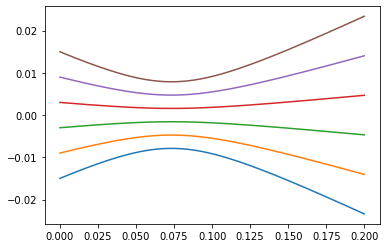

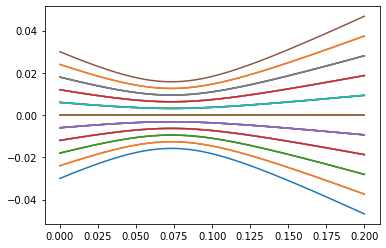

In [4]:
#generate a set of fields from zero to 100mT
Bz=np.linspace(0,200*1E-3,200)
#Unit vector along z
uvec=np.matrix([0,0,1]).T

#convert it to a vector along the our axis
B=uvec*Bz

#If we are doing simple things dynamicH suffices
    # It automatically adds the static hamiltonian if static=True
H=groundI.dynamicH(B)

#This actually conceals a few important things so to write it out in full
    #ground.H contains our static hamiltonian, 
    #it doesn't know about the dimension of the magnetic field
    #Using np.newaxis we can increase the dimension to match the zeeman data
H=np.array(groundI.H)[np.newaxis,...]-groundI.nuclearZeeman(B)

#get the eigen values F and Vectors
F,V=groundI.getEigFreq(H)

#Dimension convention makes is to aid such plotting
plt.plot(Bz,F)
plt.show()

#Calculate the transitions, noting that our transitions always lie across axis 1
T=spin.eachElemFunc(F,F,axis=1)
plt.plot(Bz,T)
plt.show()


# Gradient

dH Shape:  (3, 6, 6)


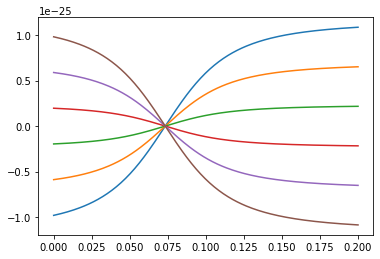

In [5]:
#This uses the default calculated hamiltonian derivative based on dynamicH
df=groundI.gradient(V)

#To be explicit we just calculate the gradient as the value at the Identity
    #This generates the three x,y,z hamiltonian elements that are then seperated
dH=-groundI.nuclearZeeman(np.eye(3))
print("dH Shape: ",dH.shape)
df=groundI.gradient(V,dH=dH)
plt.plot(Bz,df.real*uvec)
plt.show()

# Curvature

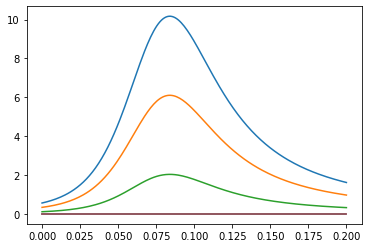

In [6]:
ddf=groundI.curvature(V,F)
#plot the maximum eigenvalue as a single proxy
Cmax=np.max(np.linalg.eig(ddf)[0],axis=-1)
plt.plot(Bz,Cmax.real)
plt.show()

# Testing

Sometimes its useful to keep this around

## Hyperfine reshape

This is trying to work out if hyperfine reshape is the intended $I\otimes A S$ or $S\otimes A I$. It seems this is the latter for the hamiltonian but it doesn't matter once we take eigenvalues


HHF (12, 12)
(4, 3)
(36, 3)
HFF-HK True
HH-HK False
HHF [ 0.05402037+0.j  0.03241222+0.j  0.01080407+0.j -0.01080407+0.j
 -0.03241222+0.j -0.05402037+0.j -0.05402037+0.j -0.03241222+0.j
 -0.01080407+0.j  0.01080407+0.j  0.03241222+0.j  0.05402037+0.j]
HK [ 0.05402037+0.j  0.03241222+0.j  0.01080407+0.j -0.01080407+0.j
 -0.03241222+0.j -0.05402037+0.j -0.05402037+0.j -0.03241222+0.j
 -0.01080407+0.j  0.01080407+0.j  0.03241222+0.j  0.05402037+0.j]
(4, 3)
(36, 3)


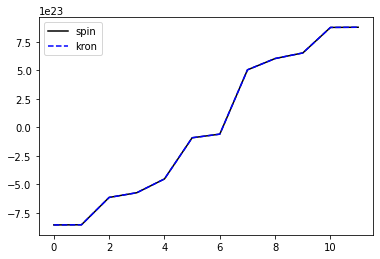

In [7]:
g=np.eye(3)
Q=np.eye(3)
Q=np.diag(np.random.random((3)))
# Q=np.diag([1,1,1])
Espin=1/2
Ispin=5/2

#Instantiates the class and sets up dimensions and spin matricies
ground = spin.cSpinHamiltonian(Espin,Ispin)
ground.setgE(g)
#ground.quadrupoleInteraction(Q)
HHF=np.array(ground.hyperfineInteraction(Q))
print("HHF",HHF.shape)


S=ground.S
I=ground.I
Idim=ground.Idim
dim=ground.dim

print(S.shape)
print(I.shape)
HH=I@Q@S.T
HH=np.array(HH.reshape(dim,dim))
FHF,_=ground.getEigFreq(HHF)
FHH,_=ground.getEigFreq(HH)

plt.plot(FHF,'k',label='spin')
# plt.plot(FHH,'k--')


#print(HHF)

#print(HH)




# np.block([[a,b.T],[c.T,d]])
def hyperfineKron(I,Q,S):
    A=np.array(Q@S.T)
    #print(A.shape)
    # A=np.sum(A,axis=0)
    # print(A.shape)


    Sx=A[0,:].reshape(2,2)
    Sy=A[1,:].reshape(2,2)
    Sz=A[2:,:].reshape(2,2)

    Ix=I[:,0].reshape(Idim,Idim)
    Iy=I[:, 1].reshape(Idim,Idim)
    Iz=I[:,2].reshape(Idim,Idim)

    HK=np.array(np.kron(Sx,Ix)+np.kron(Sy,Iy)+np.kron(Sz,Iz))
    return HK
HK=hyperfineKron(I,Q,S)
FK,_=ground.getEigFreq(HK)
plt.plot(FK,'b--',label='kron')
plt.legend()

print("HFF-HK",np.allclose(HHF,HK))
print("HH-HK",np.allclose(HH,HK))

print("HHF",np.diag(HHF))
print("HK",np.diag(HK))
# print(np.diag(HH))
HH=np.array(I@Q@S.T)
a=HH[:,0].T.reshape((Idim,Idim))
b=HH[:,1].reshape((Idim,Idim))
c=HH[:,2].reshape((Idim,Idim))
d=HH[:,3].reshape((Idim,Idim))
# print(a)
# print(b)
# print(c)
# print(d)
print(S.shape)
print(I.shape)

In [8]:
%timeit ground.hyperfineInteraction(Q)
%timeit spin.hyperquad(I,Q,S)
%timeit hyperfineKron(I,Q,S)


84.9 µs ± 19.4 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)
136 µs ± 33.3 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)
136 µs ± 30 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)


In [ ]:
Sx=S[0,:].reshape(2,2)
Sy=S[1,:].reshape(2,2)
Sz=S[2:,:].reshape(2,2)

Ix=I[:,0].reshape(Idim,Idim)
Iy=I[:, 1].reshape(Idim,Idim)
Iz=I[:,2].reshape(Idim,Idim)

np.kron(np.kron(Q,Sx))

ValueError: cannot reshape array of size 3 into shape (2,2)

: 

## Multi Spin Testing

Trying to have a nice interface to calculate the values of multiple isotopes

{'Spin': {'Espin': '1/2', 'Ispin': '1/2'}, 'E_Zeeman': {'g': 'np.matrix([[3.916,0,0],[0,3.916,0],[0,0,1.053]])', 'g_rot': 'np.array([0,0,0])'}, 'Hyperfine': {'A': 'np.matrix([[3.0819,0,0],[0,3.0819,0],[0,0,-0.789]])*1e9*h', 'A_rot': 'np.array([0,0,0])'}, 'N_Zeeman': {'mu': '0.987'}, 'Oscillator': {'par': 'np.block([[np.eye(odim),np.zeros([odim,odim])],[np.zeros([odim,odim]),np.eye(odim)]])', 'perp': 'np.block([[np.zeros([odim,odim]),1*np.eye(odim)],[np.eye(odim),np.zeros([odim,odim])]])', 'perp_T': 'np.block([[np.zeros([odim,odim]),1j*np.eye(odim)],[-1j*np.eye(odim),np.zeros([odim,odim])]])'}}
{'Spin': {'Espin': '1/2', 'Ispin': '1/2'}, 'E_Zeeman': {'g': 'np.matrix([[3.916,0,0],[0,3.916,0],[0,0,1.053]])', 'g_rot': 'np.array([0,0,0])'}, 'Hyperfine': {'A': 'np.matrix([[3.0819,0,0],[0,3.0819,0],[0,0,-0.789]])*1e9*h', 'A_rot': 'np.array([0,0,0])'}, 'N_Zeeman': {'mu': '0.987'}, 'Oscillator': {'par': 'np.block([[np.eye(odim),np.zeros([odim,odim])],[np.zeros([odim,odim]),np.eye(odim)]])', 'per

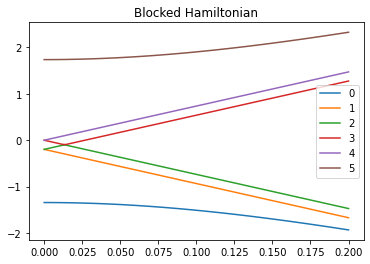



Now there is no anti crossing


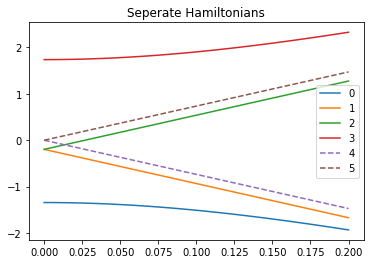

In [ ]:
YB=spin.hamilFromYAML('./ion_params/Yb_CaWO.yml')
YBE=spin.hamilFromYAML('./ion_params/Yb_CaWO.yml',IOveride=0)

Bs=np.linspace(0,200E-3,100)
uvec=np.matrix([0,0,1]).T
Bvec=np.outer(uvec,Bs)

H=YB.dynamicH(Bvec)
He=YBE.dynamicH(Bvec)


Pack=np.zeros((H.shape[0],YB.dim,YBE.dim))
Pack2=np.zeros((H.shape[0],YBE.dim,YB.dim))

Hc=np.block([[H,Pack],[Pack2,He]])


F,V=np.linalg.eigh(-1*Hc/(h*1E9))#YB.getEigFreq(Hc)
FO,VO=YB.getEigFreq(H)
FE,VE=YBE.getEigFreq(He)


OO=YB.spinTransitionStrength(VO,np.matrix([[1,0],[0,-1]]))
print("\n")
print("Note that 4 and (2,3) belong to the even isotope which shouldn't anti cross with (3,2)")
plt.title("Blocked Hamiltonian")
plt.plot(Bs,F)
plt.legend([str(i) for i in range(F.shape[1])])
# plt.plot(Bs,FO,'C0--')
# plt.plot(Bs,FE,'C1--')
#plt.plot(Bs,F[:,2],'k')
#plt.plot(Bs,FO[:,2],'k--')
plt.show()

print("\n")
print("Now there is no anti crossing")
plt.plot(Bs,FO)
plt.plot(Bs,FE,'--')
plt.title("Seperate Hamiltonians")

plt.legend([str(i) for i in range(F.shape[1])])
plt.show()



(100, 16)
(100, 4)


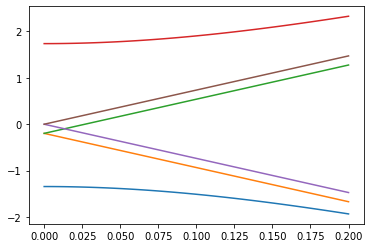

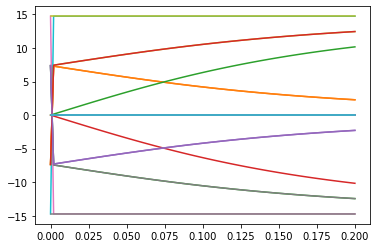

(100, 4, 4) (100, 2, 2)


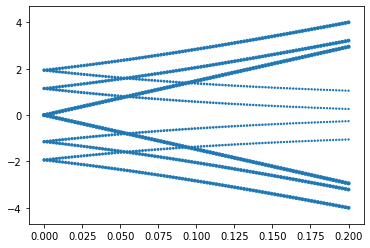

In [ ]:
# Put it all in a class
Ybs=spin.cMultiSpin([YB,YBE])
F,T=Ybs.getEigFreq(Bvec)
Fp,Tp=Ybs.gradient()
plt.plot(Bs,F)
plt.show()
plt.plot(Bs,Tp*uvec)
plt.show()
sz=np.matrix([[1,0],[0,-1]])
sx=np.matrix([[0,1],[1,0]])

print(Ybs.Vs[0].shape,Ybs.Vs[1].shape)

O=Ybs.spinTransitionStrength(sx)


plt.scatter(np.repeat(Bs[:,np.newaxis],T.shape[1],axis=1),T,O*1E1)
#plt.ylim([3,4])
#r=Ybs.dynamicH(Bvec)
#print(r)
#print(Ybs.spins)